# Transformer from Scratch

This notebook builds a small Transformer language model from scratch to make its inner mechanics transparent. We implement embeddings, causal self-attention, residual connections, and the feed-forward block directly. The full PyTorch implementation can be found in `src/utils.py`. The model uses character-level tokenization and is trained on the full text of The Wizard of Oz. It learns to predict the next character given a sequence of previous characters. By repeatedly feeding its own outputs back into the input, it can continue a prompt and generate new text in the style of the training data. Despite its small size, it learns basic English structure and can generate short, coherent text. We also use temperature and top-k sampling to improve generation quality.

In [1]:
import torch
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import utils

## Training the model

The model loads the `input.txt` file from the `data` folder, which is used as the training text. We use the full text of The Wizard of Oz, although any sufficiently large English text would work. Note that the `tokenize_text` function automatically preprocesses the text by removing line breaks and collapsing multiple spaces into a single space. This function also removes all capitalization, which reduces the size of the vocabulary and improves the model's performance.

In [2]:
_, encoded, encoder, decoder = utils.tokenize_text("../data/input.txt")
vocab_size = len(encoder)

A pre-trained model is included in the `model` folder. Running the code in this section will load that model rather than re-train it. To train a new model, simply remove the two files in the `model` folder before running the code below.

The model’s performance depends heavily on how much training time it receives. In this project, the goal is to use configurations that can be trained overnight on a laptop. The parameter choices below are selected to maximize model quality within that time budget.

In [3]:
block_size = 64
batch_size = 16

dim = 64
n_transformers = 3

min_epochs = 10
max_epochs = 50
patience = 10
lr = 5e-4

Parameter `block_size` is the model’s context length, i.e. how far it looks back when predicting the next character. `batch_size` controls how many samples are processed together in each training step. `dim` is the dimensionality of the internal vector space in which tokens are represented, and `n_transformers` sets the number of Transformer layers in the model.

`min_epochs` specifies the minimum number of epochs the model will train, while `max_epochs` sets the upper limit. Early stopping is triggered if validation loss stops improving; the `patience` value determines how many consecutive epochs of non-improvement are allowed before training terminates. In practice, for small language models trained on a reasonably large dataset, overfitting is unlikely, so the model will usually run all the way to `max_epochs`.

In general, the training time of this model scales approximately as follows:

$$
\text{training time} \sim \text{number of epochs} \times \text{number of transformers} \times (\text{block size})^2 \times (\text{dimension})^2
$$

Assuming The Wizard of Oz is used as the training and validation dataset, training this model with the parameter values above on an M1 MacBook Pro takes roughly eight hours using MPS (Apple’s GPU backend, analogous to CUDA on NVIDIA hardware). The code automatically detects whether MPS or CUDA is available and uses it when possible.

The code below trains the model. If a pre-trained `model.pt` file is present in the `model` directory, it will be loaded instead, and training will be skipped.

In [4]:
train_loader, valid_loader = utils.prepare_dataloaders(encoded, block_size, batch_size = batch_size)
model = utils.LanguageModel(vocab_size, block_size, dim, n_transformers)

model_path = "../model/model.pt"
history_path = "../model/history.pt"

if os.path.exists(model_path):
    print("Loading model from disk...")
    model.load_state_dict(torch.load(model_path, map_location = "cpu"))
    if os.path.exists(history_path):
        print("Loading history from disk...")
        history = torch.load(history_path)
    else:
        print("History not found. Model loaded without history.")
        history = None
else:
    print("Training model...")
    model, history = utils.train_model(
        model,
        train_loader,
        valid_loader,
        lr = lr,
        min_epochs = min_epochs,
        max_epochs = max_epochs,
        patience = patience
    )
    print("Saving model and history...")
    torch.save(model.state_dict(), model_path)
    torch.save(history, history_path)

Loading model from disk...
Loading history from disk...


Plotting the training and validation losses over the epochs shows steady improvement with no evidence of overfitting.

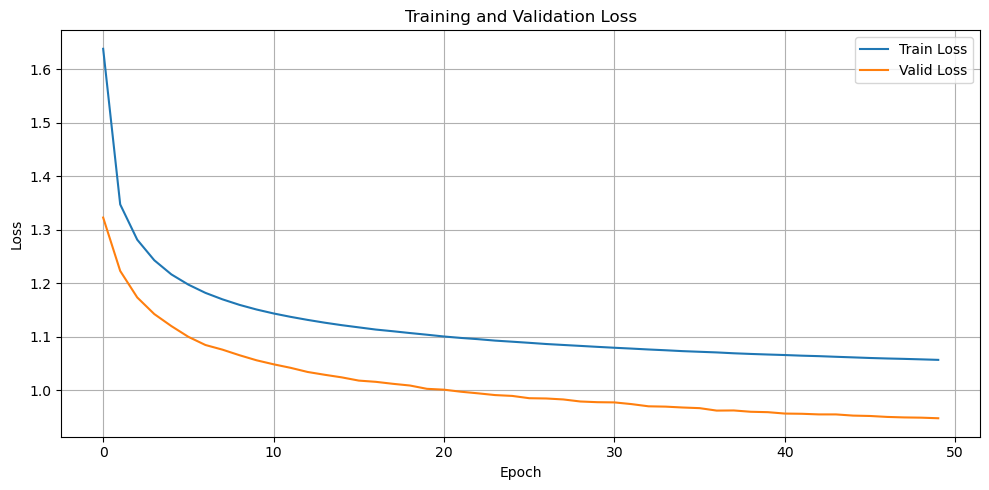

In [5]:
utils.plot_loss_history(history)

## Basic output decoding

With the model trained, we can evaluate its behavior by asking it to complete several simple prompt sentences that are consistent with the style and content of the training text. This is done by repeatedly using the model to predict the next character until it produces a sentence-ending symbol (.?!).

In [6]:
prompts = [
    "Dorothy is from ",
    "Dorothy said ",
    "The wizard of Oz is ",
    "Lion was a ",
    "The Witch wanted to"
]

for p in prompts:
    out = utils.forecast_sentence(model, p, encoder = encoder, decoder = decoder, block_size = block_size, temperature = 1, top_k = 10)
    print("Prompt:    ", repr(p))
    print("Completed: ", repr(out))
    print()

Prompt:     'Dorothy is from '
Completed:  'dorothy is from the south stern through the air.'

Prompt:     'Dorothy said '
Completed:  'dorothy said headle, where the more.'

Prompt:     'The wizard of Oz is '
Completed:  'the wizard of oz is the scarecrow and she stood upon the charm of the flowers of the soldier with any other picks.'

Prompt:     'Lion was a '
Completed:  'lion was a good wizard with wonderful clowns.'

Prompt:     'The Witch wanted to'
Completed:  'the witch wanted to see him.'



One can see that while the model occasionally invents non-existent words and loses coherence in longer sentences, the short continuations it produces are often grammatically correct and reasonably coherent. Many of its limitations stem from the need for probabilistic decoding, which introduces randomness into the generated output. The role of this randomness, why deterministic decoding performs poorly, and how different sampling settings affect the stability of the model’s responses will be discussed in the next section.

Unfortunately, the model cannot answer questions. It does not attempt to respond to the prompt but simply to continue it. In the text of The Wizard of Oz, as in many novels where dialogue is written with “...” notation, a question mark is almost always followed by a closing quotation mark. As a result, the model tends to produce completions like this:

In [9]:
prompt = "Who are you?"
out = utils.forecast_sentence(model, prompt, encoder = encoder, decoder = decoder, block_size = block_size, temperature = 1, top_k = 10)
print("Prompt:    ", repr(prompt))
print("Completed: ", repr(out))

Prompt:     'Who are you?'
Completed:  'who are you?” asked oz.'


Note that the model does “understand” that the prompt is a question; it simply does not interpret the question as being directed at it. For a character-level model trained purely to extend text, a question mark is just another symbol to continue from, not an instruction to answer.

## Different ways to decode the output

The model outputs a vector of logits that represent its preference for each possible next token. The simplest way to decode is greedy (argmax) decoding: at each step, pick the single most likely token. This approach is usually poor in practice, because it drives the model into repetitive loops. For The Wizard of Oz, the model gravitates toward variations of infinitely repeated “and the scarecrow,” regardless of the initial prompt.

A better approach is categorical sampling: choose the next token at random, weighted by the model’s predicted probabilities. This produces more varied and interesting continuations, though at the cost of greater instability.

The temperature parameter is used to adjust the sharpness of the probability distribution. Increasing temperature flattens the distribution and encourages more randomness; decreasing it sharpens the distribution and makes sampling behave more like greedy selection. Temperature = 1 corresponds to standard softmax sampling. Taking temperature toward zero recovers the deterministic argmax limit, while taking it very large yields chaotic, nearly uniform random outputs.

Here are the results for completing the same prompt at several temperature settings:

In [11]:
prompt = "Dorothy thought that "
print("Prompt:    ", repr(prompt))
print()
out = utils.forecast(model, prompt, horizon = 120, encoder = encoder, decoder = decoder, block_size = block_size)
print(f"Completed with argmax : ", repr(out))
for temperature in [10 ** x for x in torch.linspace(-0.99, 0.99, steps = 11)]:
    out = utils.forecast(model, prompt, horizon = 120, encoder = encoder, decoder = decoder, block_size = block_size, temperature = temperature, top_k = 10)
    print(f"Completed at temp {temperature:.2f}: ", repr(out))

Prompt:     'Dorothy thought that '

Completed with argmax :  'dorothy thought that the scarecrow and the scarecrow and the scarecrow said: “i am oz, the scarecrow morning to the trees and the scarecrow a'
Completed at temp 0.10:  'dorothy thought that the scarecrow and the scarecrow said: “we must go to the scarecrow morning to the project gutenberg literary archive fou'
Completed at temp 0.16:  'dorothy thought that the scarecrow and the scarecrow and the scarecrow said: “we must go to the cowardly lion and the lion and the lion went '
Completed at temp 0.25:  'dorothy thought that the scarecrow and the lion went to the cowardly lion and the lion and the wicked witch of the wicked witch of the west. '
Completed at temp 0.40:  'dorothy thought that the great lion carried her legs and said, “and the witch the wicked witch the wicked witch of the wicked witch of the gr'
Completed at temp 0.63:  'dorothy thought that she would not be here turned, and she sat down to the tin woodman were 

We also use the `top_k` parameter to restrict the model to its most likely candidates and avoid low-probability tail events. Reducing `top_k` makes the sampling more stable and conservative, since fewer unlikely tokens are ever considered. To illustrate this, we complete the same prompt for different values of `top_k`:

In [12]:
prompt = "Dorothy decided to "
print("Prompt:    ", repr(prompt))
print()
for top_k in range(1, 13):
    out = utils.forecast(model, prompt, horizon = 120, encoder = encoder, decoder = decoder, block_size = block_size, temperature = 1, top_k = top_k)
    print(f"Completed with top_k = {top_k}: ", repr(out))

Prompt:     'Dorothy decided to '

Completed with top_k = 1:  'dorothy decided to the scarecrow and the scarecrow and the scarecrow said: “i am oz, the scarecrow morning to the trees and the scarecrow a'
Completed with top_k = 2:  'dorothy decided to think and soon said: “i am all the stranger into the cowardly lion and then he stood upon the scarecrow said, “where is '
Completed with top_k = 3:  'dorothy decided to see on a small. “why do you wish to get her stands of the woodman were tigers to see of the wicked witch and set him to '
Completed with top_k = 4:  'dorothy decided to the winkies, who was toto come for her and became and done! oh, so much states. the scarecrow and the ladder was a lift '
Completed with top_k = 5:  'dorothy decided to the scarecrow, indeed her arms and broken him to get him to get back to have the stopped of the woodman and then he said'
Completed with top_k = 6:  'dorothy decided to the wicked witch of and that it was not after them, while the wicked witc

## Conclusions

We implemented a character-level Transformer language model from scratch and trained it overnight on The Wizard of Oz. Despite its small size, the model learned basic English structure and can produce coherent short-range continuations, especially when using temperature and top-k sampling. Its limitations (short context, small embedding dimension, and character-level tokenizing) lead to drifting and occasional nonsense, which are expected at this scale.